In [287]:
import json
import re
from bert_score import score
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import random
import json
import os
import re
from textblob import TextBlob
from scipy.stats import spearmanr, kendalltau, linregress

In [307]:
YEAR = 2024
associations_valid = [('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_' + str(YEAR) + '_abstract_prompts_gpt4o_results.jsonl', str(YEAR) + ' GPT4o-Abstract-Zeroshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_' + str(YEAR) + '_abstract_prompts_oneshot_gpt4o_results.jsonl', str(YEAR) + ' GPT4o-Abstract-Oneshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_' + str(YEAR) + '_abstract_prompts_fewshot_gpt4o_results.jsonl', str(YEAR) + ' GPT4o-Abstract-Fewshot'),
                      
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_' + str(YEAR) + '_summary_prompts_gpt4o_results.jsonl', str(YEAR) + ' GPT4o-Summary-Zeroshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_' + str(YEAR) + '_summary_prompts_oneshot_gpt4o_results.jsonl', str(YEAR) + ' GPT4o-Summary-Oneshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_' + str(YEAR) + '_summary_prompts_fewshot_gpt4o_results.jsonl', str(YEAR) + ' GPT4o-Summary-Fewshot'),

                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_' + str(YEAR) + '_full text_prompts_gpt4o_results.jsonl', str(YEAR) + ' GPT4o-Full_Text-Zeroshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_' + str(YEAR) + '_full text_prompts_oneshot_gpt4o_results.jsonl', str(YEAR) + ' GPT4o-Full_Text-Oneshot'),
                      
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/zero_shot_' + str(YEAR) + '_abstract_prompts.jsonl', str(YEAR) + ' Llama-Abstract-Zeroshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/one_shot_' + str(YEAR) + '_abstract_prompts.jsonl', str(YEAR) + ' Llama-Abstract-Oneshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/few_shot_' + str(YEAR) + '_abstract_prompts.jsonl', str(YEAR) + ' Llama-Abstract-Fewshot'),

                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/zero_shot_' + str(YEAR) + '_summary_prompts.jsonl', str(YEAR) + ' Llama-Summary-Zeroshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/one_shot_' + str(YEAR) + '_summary_prompts.jsonl', str(YEAR) + ' Llama-Summary-Oneshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/few_shot_' + str(YEAR) + '_summary_prompts.jsonl', str(YEAR) + ' Llama-Summary-Fewshot'),

                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/zero_shot_' + str(YEAR) + '_full text_prompts.jsonl', str(YEAR) + ' Llama-Full Text-Zeroshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/one_shot_' + str(YEAR) + '_full text_prompts.jsonl', str(YEAR) + ' Llama-Full Text-Oneshot'),

                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_abstract_prompts_fewshot.jsonl', 'results/hundred_shot_test_data_' + str(YEAR) + '_abstract_prompts.jsonl', str(YEAR) + ' Llama-Abstract-100'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_abstract_prompts_fewshot.jsonl', 'results/hundred_shot_test_data_' + str(YEAR) + '_summary_prompts.jsonl', str(YEAR) + ' Llama-Summary-100'),

                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_abstract_prompts_fewshot.jsonl', 'results/thousand_shot_test_data_' + str(YEAR) + '_abstract_prompts.jsonl', str(YEAR) + ' Llama-Abstract-1000'),
                      
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_' + str(YEAR) + '_abstract_prompts_fewshot.jsonl', 'results/time_ordered_instruct_test_data_' + str(YEAR) + '_abstract_prompts_with_timestamp.jsonl', str(YEAR) + ' Llama Time Finetuned'),]

# associations_valid = [('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/zero_shot_2025_summary_prompts.jsonl', 'Llama-Summary-Zeroshot'),
#                       ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/one_shot_2025_summary_prompts.jsonl', 'Llama-Summary-Oneshot'),
#                       ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/few_shot_2025_summary_prompts.jsonl', 'Llama-Summary-Fewshot'),
#                       ('data/test_data/test_data_without_timestamp/few_shot/test_data_2024_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/few_shot_2024_summary_prompts.jsonl', 'Llama-Summary-Fewshot'),]
# #associations_valid = [('data/test_data/few_shot/test_data_2024_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2024_abstract_prompts_fewshot_gpt4o_results.jsonl', 'GPT4o-Abstract-Fewshot')]

# associations_test = [('data/test_data/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_abstract_prompts_fewshot_gpt4o_results.jsonl', 'GPT4o-Abstract-Fewshot'),
#                      ('data/test_data/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_abstract_prompts_oneshot_gpt4o_results.jsonl', 'GPT4o-Abstract-Oneshot'),
#                      ('data/test_data/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_abstract_prompts_gpt4o_results.jsonl', 'GPT4o-Abstract-Zeroshot'),
#                      ('data/test_data/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_summary_prompts_fewshot_gpt4o_results.jsonl', 'GPT4o-Summary-Fewshot'),
#                      ('data/test_data/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_summary_prompts_oneshot_gpt4o_results.jsonl', 'GPT4o-Summary-Oneshot'),
#                      ('data/test_data/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_summary_prompts_gpt4o_results.jsonl', 'GPT4o-Summary-Zeroshot'),
#                      ('data/test_data/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_full text_prompts_oneshot_gpt4o_results.jsonl', 'GPT4o-Full_Text-Oneshot'),
#                      ('data/test_data/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_full text_prompts_gpt4o_results.jsonl', 'GPT4o-Full_Text-Zeroshot')]


In [ ]:
from parse_results import fix_missing_quotes_and_braces
def get_gold_and_predictions(association):
    with open(association[0], 'r') as f:
        gold_standard = [json.loads(line) for line in f]
        #gold_standard = json.load(f)

    gold_standard = [{item['paper_id']:json.loads(item['messages'][-1]['content'])} for item in gold_standard]
    #predictions = [{item['paper_id']:item['review']} for item in predictions if 'review' in item.keys()]
    #predictions = [{item['paper_id']:json.loads(item['review'])} for item in predictions if 'review' in item.keys()]
    try:
        predictions = [{json.loads(item)['paper_id']: json.loads(json.loads(item)['review'])} for item in fix_missing_quotes_and_braces(association[1], 'test.json')]
    except:
        with open(association[1], 'r') as f:
            predictions = [json.loads(line) for line in f]
        predictions = [{item['paper_id']:item['review']} for item in predictions if 'review' in item.keys()]

    return gold_standard, predictions

device = "mps" if torch.backends.mps.is_available() else "cpu"
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

In [171]:
associations_valid[0]

('data/test_data/few_shot/test_data_2024_summary_prompts_fewshot.jsonl',
 'results/llama3_8BInstruct/one_shot_2024_abstract_prompts.jsonl',
 'Llama-Abstract-Oneshot')

In [270]:
def calc_bertscore(gold_cat, pred_cat):
    bert = score(gold_cat.tolist(), pred_cat.tolist(), lang="en")
    mean_precision = torch.mean(bert[0])
    mean_recall = torch.mean(bert[1])
    mean_f1 = torch.mean(bert[2])
    return float(mean_precision), float(mean_recall), float(mean_f1)

In [271]:
def confusion_matrix_gen(num_pred, num_gold):
    num_pred = np.array(num_pred)
    num_gold = np.array(num_gold)

    soundness_conf = confusion_matrix(num_pred[:,0], num_gold[:,0], labels=[1,2,3,4])
    presentation_conf = confusion_matrix(num_pred[:,1], num_gold[:,1], labels=[1,2,3,4])
    contribution_conf = confusion_matrix(num_pred[:,2], num_gold[:,2], labels=[1,2,3,4])
    rating_conf = confusion_matrix(num_pred[:,3], num_gold[:,3], labels=[1,2,3,4,5,6,7,8,9,10])
    confidence_conf = confusion_matrix(num_pred[:,4], num_gold[:,4], labels=[1,2,3,4])

    return(soundness_conf, presentation_conf, contribution_conf, rating_conf, confidence_conf)

In [272]:
def score_results(scores):
    scores_dict = {}
    for score in scores:
        tot_score = 0
        for key in ['Soundness', 'Presentation', 'Contribution', 'Rating', 'Confidence']:
            tot_score += list(score.values())[0][key]
        try:
            list(score.values())[0]['Weaknesses']
            tot_score += (TextBlob(list(score.values())[0]['Strengths']).sentiment.polarity - np.abs(TextBlob(list(score.values())[0]['Weaknesses']).sentiment.polarity))
        except:
            tot_score += 0
        scores_dict[list(score.keys())[0]] = tot_score
    sorted_items = sorted(scores_dict.items(), key=lambda item: item[1], reverse=True)
    ranked_values = {}
    rank = 1
    for key, value in sorted_items:
        ranked_values[key] = rank
        rank += 1
    return ranked_values

In [273]:
def score_results1(scores):
    scores_dict = {}
    
    for score in scores:
        paper_id = list(score.keys())[0]
        details = list(score.values())[0]
        
        ranking_criteria = (
            details['Rating'], 
            details['Contribution'], 
            details['Soundness'], 
            details['Confidence'], 
            details['Presentation']
        )
        
        scores_dict[paper_id] = ranking_criteria
    
    sorted_items = sorted(scores_dict.items(), key=lambda item: item[1], reverse=True)
    
    ranked_values = {}
    rank = 1
    for key, _ in sorted_items:
        ranked_values[key] = rank
        rank += 1
    
    return ranked_values

In [274]:
def top_nk(n, k, gold_scores_rank, pred_scores_rank):
    top_n = list(gold_scores_rank)[0:int(n*len(gold_scores_rank)/100)]
    top_k = list(pred_scores_rank)[0:int(k*len(pred_scores_rank)/100)]
    return len(set(top_n).intersection(set(top_k)))

In [275]:
def filter_by_rating(data, threshold=5):
    return {k: v['Rating'] for item in data for k, v in item.items() if v['Rating'] > threshold}

In [293]:
np.array(gold_rank)*slope

array([17.29016483,  6.11481439, 18.55529884, 18.34444317, 20.03128852,
        8.01251541, 16.65759782, 13.70561846,  6.32567006, 14.33818547,
       15.60331948, 19.82043285,  3.58454637, 14.1273298 , 15.39246381,
       11.80791744, 14.7598968 ,  5.69310305,  8.43422675,  3.16283503,
       10.33192776, 12.44048445, 20.24214419, 21.08556686, 10.7536391 ,
        4.63882471,  5.48224738,  8.64508241,  2.95197936, 20.45299986,
       10.12107209,  4.0062577 ,  1.47598968, 10.54278343,  3.3736907 ,
        4.42796904,  3.79540204, 12.86219579, 12.65134012,  1.68684535,
       19.60957718, 11.59706177,  2.10855669,  2.53026802, 11.38620611,
       20.87471119,  9.69936076,  4.84968038, 11.17535044,  0.42171134,
        5.90395872,  6.7473814 ,  9.91021643,  8.85593808, 19.18786584,
        0.21085567, 12.22962878, 17.07930916,  7.16909273,  0.84342267,
       13.28390712, 13.07305145,  6.95823706, 17.92273183,  2.31941235,
       19.39872151, 13.49476279, 18.1335875 , 12.01877311,  9.06

In [ ]:
numerical_scores = ["Soundness", "Presentation", "Contribution", "Rating", "Confidence"]
text_fields = ["Strengths", "Weaknesses"]#, "Questions"]

results_list = []

for association in associations_valid:
    gold_standard, predictions = get_gold_and_predictions(association)

    pred_filtered = filter_by_rating(predictions)
    gold_filtered = filter_by_rating(gold_standard)

    gold_scores = []
    pred_scores = []

    gold_text = []
    pred_text = []
    for prediction in predictions:
        gold = list([item for item in gold_standard if item.keys() == prediction.keys()][0].values())[0]
        prediction = list(prediction.values())[0]

        gold_scores.append([gold[category] for category in numerical_scores])
        pred_scores.append([prediction[category] for category in numerical_scores])

        try:
            prediction['Weaknesses']
            gold_text.append([gold[category] for category in text_fields])
            pred_text.append([prediction[category] for category in text_fields])
        except:
            continue
    gold_scores = np.array(gold_scores)
    pred_scores = np.array(pred_scores)

    gold_text = np.array(gold_text)
    pred_text = np.array(pred_text)

    mean_precision_strengths, mean_recall_strengths, mean_f1_strengths = calc_bertscore(gold_text[:,0], pred_text[:,0])
    mean_precision_weaknesses, mean_recall_weaknesses, mean_f1_weaknesses = calc_bertscore(gold_text[:,1], pred_text[:,1])
    #mean_precision_questions, mean_recall_questions, mean_f1_questions = calc_bertscore(gold_text[:,2], pred_text[:,2])

    all_embeddings = np.vstack([
        model.encode(pred_text[:,0]), model.encode(gold_text[:,0]),
        model.encode(pred_text[:,1]), model.encode(gold_text[:,1]),
        #model.encode(pred_text[:,2]), model.encode(gold_text[:,2]),
    ])
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(all_embeddings)
    split_idx = len(pred_text[:,0])
    pred_str_2d = embeddings_2d[:split_idx]
    gold_str_2d = embeddings_2d[split_idx:2*split_idx]
    pred_weak_2d = embeddings_2d[2*split_idx:3*split_idx]
    gold_weak_2d = embeddings_2d[3*split_idx:4*split_idx]
    pred_ques_2d = embeddings_2d[4*split_idx:5*split_idx]
    gold_ques_2d = embeddings_2d[5*split_idx:]

    categories = [
    ("Strengths", pred_str_2d, gold_str_2d, 'blue'),
    ("Weaknesses", pred_weak_2d, gold_weak_2d, 'red'),
    ("Questions", pred_ques_2d, gold_ques_2d, 'green')
    ]

    for label, pred, gold, color in categories:
        plt.scatter(pred[:, 0], pred[:, 1], marker='o', label=f"{label} (Pred)", color=color, alpha=0.6)
        plt.scatter(gold[:, 0], gold[:, 1], marker='x', label=f"{label} (Gold)", color=color, alpha=0.9)
        
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("Embedding Visualization: Predicted vs Gold Standard")
    plt.legend()
    plt.grid()
    plt.show()
    
    gold_scores_rank = score_results(gold_standard)
    pred_scores_rank = score_results(predictions)
    gold_scores_rank_rating = score_results1(gold_standard)
    pred_scores_rank_rating = score_results1(predictions)
    gold_rank = []
    pred_rank = []
    gold_rank_rating = []
    pred_rank_rating = []
    standard_keys = [list(item.keys())[0] for item in gold_standard]
    for key in standard_keys:
        if key in pred_scores_rank.keys():
            gold_rank.append(gold_scores_rank[key])
            pred_rank.append(pred_scores_rank[key])
            gold_rank_rating.append(gold_scores_rank_rating[key])
            pred_rank_rating.append(pred_scores_rank_rating[key])

    all_paper_ids = set(pred_filtered.keys()).union(set(gold_filtered.keys()))
    y_pred = [1 if pid in pred_filtered else 0 for pid in all_paper_ids]
    y_true = [1 if pid in gold_filtered else 0 for pid in all_paper_ids]
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    TP = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TN = cm[1, 1]

    plt.scatter(gold_rank, pred_rank)
    slope, intercept, r_value, p_value, std_err = linregress(gold_rank, pred_rank)
    y_predicted = slope * np.array(gold_rank) + intercept
    plt.plot(gold_rank, y_predicted, color='red', label=f'Best Fit Line: y = {slope:.2f}x + {intercept:.2f}')
    plt.text(0.1, 0.9, f'r: {r_value:.2f}', transform=plt.gca().transAxes, color='red')
    plt.xlabel('Gold Rank')
    plt.ylabel('Predicted Rank')
    plt.title(association[2] + ' Total Rank Scatter')
    plt.show()

    plt.scatter(gold_rank_rating, pred_rank_rating)
    slope, intercept, r_value, p_value, std_err = linregress(gold_rank_rating, pred_rank_rating)
    y_predicted = slope * np.array(gold_rank_rating) + intercept
    plt.plot(gold_rank_rating, y_predicted, color='red', label=f'Best Fit Line: y = {slope:.2f}x + {intercept:.2f}')
    plt.text(0.1, 0.9, f'r: {r_value:.2f}', transform=plt.gca().transAxes, color='red')
    plt.xlabel('Gold Rank')
    plt.ylabel('Predicted Rank')
    plt.title(association[2] + ' Rating Rank Scatter')
    plt.show()

    print(association[2] + ' MSE_soundness = ' + str(mean_squared_error(gold_scores[:,0], pred_scores[:,0])))
    print(association[2] + ' MSE_presentation = ' + str(mean_squared_error(gold_scores[:,1], pred_scores[:,1])))
    print(association[2] + ' MSE_contribution = ' + str(mean_squared_error(gold_scores[:,2], pred_scores[:,2])))
    print(association[2] + ' MSE_rating = ' + str(mean_squared_error(gold_scores[:,3], pred_scores[:,3])))
    print(association[2] + ' MSE_confidence = ' + str(mean_squared_error(gold_scores[:,4], pred_scores[:,4])))
    print(association[2] + ' Strengths_BertScore = ' + str(mean_precision_strengths) + ' / ' + str(mean_recall_strengths) + ' / ' + str(mean_f1_strengths))
    print(association[2] + ' Weaknesses_BertScore = ' + str(mean_precision_weaknesses) + ' / ' + str(mean_recall_weaknesses) + ' / ' + str(mean_f1_weaknesses))
    print(association[2] + ' Rank_Spearman = Stat:' + str(spearmanr(gold_rank, pred_rank)[0]) + ' P-Value:' + str(spearmanr(gold_rank, pred_rank)[1]))
    print(association[2] + ' Rank_Spearman_Rating = Stat:' + str(spearmanr(gold_rank_rating, pred_rank_rating)[0]) + ' P-Value:' + str(spearmanr(gold_rank_rating, pred_rank_rating)[1]))
    print(association[2] + ' Rank_Kendall = Stat:' + str(kendalltau(gold_rank, pred_rank)[0]) + ' P-Value:' + str(kendalltau(gold_rank, pred_rank)[1]))
    print(association[2] + ' Rank_Kendall_Rating = Stat:' + str(kendalltau(gold_rank_rating, pred_rank_rating)[0]) + ' P-Value:' + str(kendalltau(gold_rank_rating, pred_rank_rating)[1]))

    print(association[2] + 
          ' Top_5_5 = ' + str(top_nk(5, 5, gold_scores_rank, pred_scores_rank)) + 
          ' Top_5_25 = ' + str(top_nk(5, 25, gold_scores_rank, pred_scores_rank)) +
          ' Top_10_10 = ' + str(top_nk(10, 10, gold_scores_rank, pred_scores_rank)) + 
          ' Top_10_50 = ' + str(top_nk(10, 50, gold_scores_rank, pred_scores_rank)) + 
          ' Top_20_20 = ' + str(top_nk(20, 20, gold_scores_rank, pred_scores_rank)) +
          ' Top_20_50 = ' + str(top_nk(20, 50, gold_scores_rank, pred_scores_rank)))
    print(association[2] + ' Confusion Matrix = ' + str(cm))
    #print(association[2] + ' Questions_BertScore = ' + str(mean_precision_questions) + ' / ' + str(mean_recall_questions) + ' / ' + str(mean_f1_questions))
    print('\n')

    results_list.append({
        "Model": association[2],
        "MSE_Soundness": mean_squared_error(gold_scores[:, 0], pred_scores[:, 0]),
        "MSE_Presentation": mean_squared_error(gold_scores[:, 1], pred_scores[:, 1]),
        "MSE_Contribution": mean_squared_error(gold_scores[:, 2], pred_scores[:, 2]),
        "MSE_Rating": mean_squared_error(gold_scores[:, 3], pred_scores[:, 3]),
        "MSE_Confidence": mean_squared_error(gold_scores[:, 4], pred_scores[:, 4]),
        "Strengths_Precision": mean_precision_strengths,
        "Strengths_Recall": mean_recall_strengths,
        "Strengths_F1": mean_f1_strengths,
        "Weaknesses_Precision": mean_precision_weaknesses,
        "Weaknesses_Recall": mean_recall_weaknesses,
        "Weaknesses_F1": mean_f1_weaknesses,
        "Rank_Spearman_Stat": spearmanr(gold_rank, pred_rank)[0],
        "Rank_Spearman_PValue": spearmanr(gold_rank, pred_rank)[1],
        "Rank_Spearman_Rating_Stat": spearmanr(gold_rank_rating, pred_rank_rating)[0],
        "Rank_Spearman_Rating_PValue": spearmanr(gold_rank_rating, pred_rank_rating)[1],
        "Rank_Kendall_Stat": kendalltau(gold_rank, pred_rank)[0],
        "Rank_Kendall_PValue": kendalltau(gold_rank, pred_rank)[1],
        "Rank_Kendall_Rating_Stat": kendalltau(gold_rank_rating, pred_rank_rating)[0],
        "Rank_Kendall_Rating_PValue": kendalltau(gold_rank_rating, pred_rank_rating)[1],
        "Top_5_5": top_nk(5, 5, gold_scores_rank, pred_scores_rank),
        "Top_5_25": top_nk(5, 25, gold_scores_rank, pred_scores_rank),
        "Top_10_10": top_nk(10, 10, gold_scores_rank, pred_scores_rank),
        "Top_10_50": top_nk(10, 50, gold_scores_rank, pred_scores_rank),
        "Top_20_20": top_nk(20, 20, gold_scores_rank, pred_scores_rank),
        "Top_20_50": top_nk(20, 50, gold_scores_rank, pred_scores_rank),
        "Top_5_5 (rating)": top_nk(5, 5, gold_scores_rank_rating, pred_scores_rank_rating),
        "Top_5_25 (rating)": top_nk(5, 25, gold_scores_rank_rating, pred_scores_rank_rating),
        "Top_10_10 (rating)": top_nk(10, 10, gold_scores_rank_rating, pred_scores_rank_rating),
        "Top_10_50 (rating)": top_nk(10, 50, gold_scores_rank_rating, pred_scores_rank_rating),
        "Top_20_20 (rating)": top_nk(20, 20, gold_scores_rank_rating, pred_scores_rank_rating),
        "Top_20_50 (rating)": top_nk(20, 50, gold_scores_rank_rating, pred_scores_rank_rating),
        'TruePositives': TP,
        'FalsePositives': FP,
        'FalseNegatives': FN,
        'TrueNegatives': TN
    })


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


KeyboardInterrupt: 

In [ ]:
valid_statistics = pd.DataFrame(results_list)
with pd.ExcelWriter('Analysis 2024.xlsx', mode='w', engine='openpyxl') as writer:
    valid_statistics.to_excel(writer)

,Model,MSE_Soundness,MSE_Presentation,MSE_Contribution,MSE_Rating,MSE_Confidence,Strengths_Precision,Strengths_Recall,Strengths_F1,Weaknesses_Precision,...,Top_5_5 (rating),Top_5_25 (rating),Top_10_10 (rating),Top_10_50 (rating),Top_20_20 (rating),Top_20_50 (rating),TruePositives,FalsePositives,FalseNegatives,TrueNegatives
0,2024 GPT4o-Abstract-Zeroshot,1.949495,1.444444,2.808081,9.969697,0.646465,0.856266,0.868674,0.862227,0.809750,...,0,1,0,4,3,9,30,0,69,0
1,2024 GPT4o-Abstract-Oneshot,2.050505,1.454545,2.313131,9.242424,0.676768,0.863736,0.858842,0.861105,0.817469,...,0,1,0,6,5,12,30,0,69,0
2,2024 GPT4o-Abstract-Fewshot,1.867347,1.336735,2.346939,9.438776,0.663265,0.862318,0.857756,0.859868,0.816474,...,0,1,1,4,3,8,30,0,68,0
3,2024 GPT4o-Summary-Zeroshot,2.140000,1.280000,2.990000,11.050000,0.600000,0.858179,0.865927,0.861853,0.810177,...,0,0,0,4,2,9,30,0,70,0
4,2024 GPT4o-Summary-Oneshot,2.220000,2.030000,2.560000,10.650000,0.590000,0.864991,0.857089,0.860864,0.818642,...,0,1,0,5,3,9,30,0,70,0
5,2024 GPT4o-Summary-Fewshot,2.110000,1.420000,2.470000,10.820000,0.670000,0.861705,0.856283,0.858823,0.818106,...,1,1,1,6,3,11,30,0,70,0
6,2024 GPT4o-Full_Text-Zeroshot,1.590000,1.320000,2.290000,7.950000,0.730000,0.860082,0.862655,0.861179,0.813509,...,0,4,1,8,8,12,30,0,70,0
7,2024 GPT4o-Full_Text-Oneshot,2.030612,2.081633,2.193878,9.704082,0.765306,0.866914,0.854971,0.860735,0.820729,...,0,1,0,6,5,10,29,1,69,0
8,2024 Llama-Abstract-Zeroshot,2.540000,2.120000,3.420000,17.910000,1.830000,0.842726,0.862463,0.852321,0.783765,...,0,0,0,5,4,11,30,0,70,0
9,2024 Llama-Abstract-Oneshot,2.217391,2.326087,2.945652,16.054348,1.684783,0.867737,0.860617,0.863980,0.812554,...,0,0,0,3,6,9,27,3,65,0


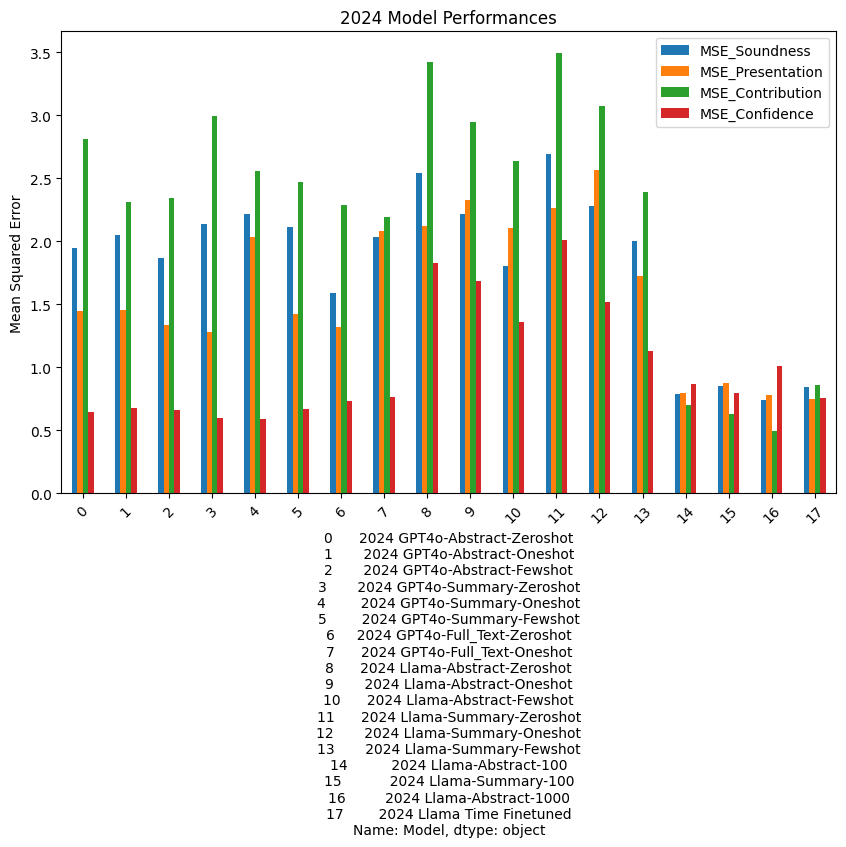

In [306]:
columns_to_plot = ['MSE_Soundness', 'MSE_Presentation', 'MSE_Contribution', 'MSE_Confidence']
df_selected = valid_statistics[columns_to_plot]

# Plot the values
df_selected.plot(kind='bar', figsize=(10, 6))

# Customize the plot
plt.xlabel(valid_statistics['Model'])
plt.ylabel("Mean Squared Error")
plt.title("2024 Model Performances")
plt.legend(df_selected.columns)
plt.xticks(rotation=45)
plt.show()

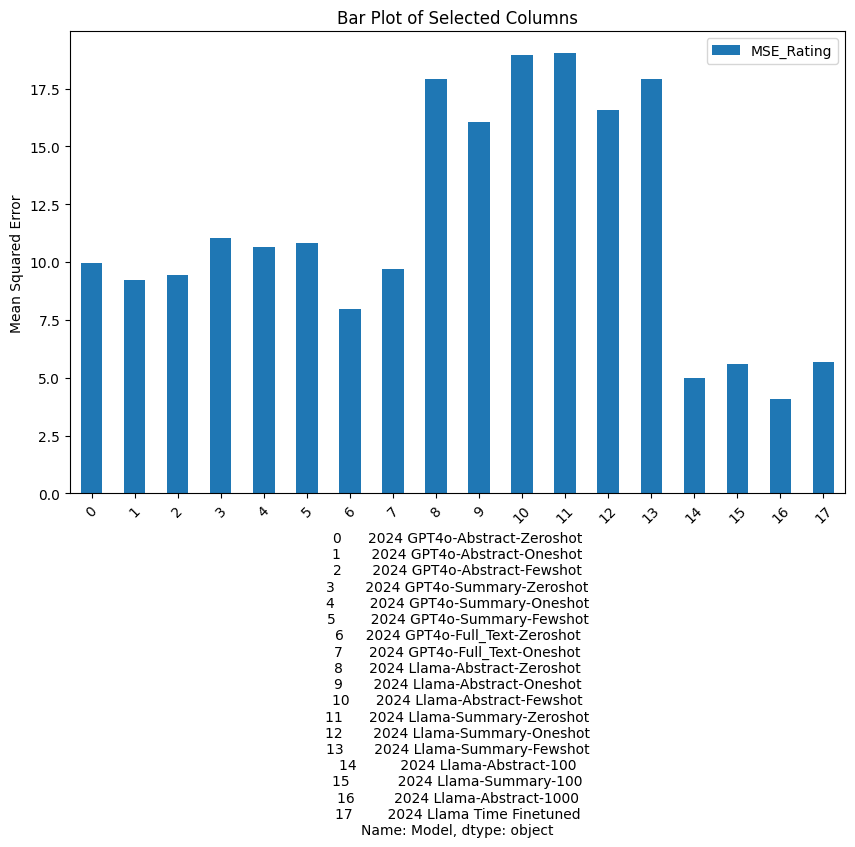

In [305]:
columns_to_plot = ['MSE_Rating']
df_selected = valid_statistics[columns_to_plot]

# Plot the values
df_selected.plot(kind='bar', figsize=(10, 6))

# Customize the plot
plt.xlabel(valid_statistics['Model'])
plt.ylabel("Mean Squared Error")
plt.title("Bar Plot of Selected Columns")
plt.legend(df_selected.columns)
plt.xticks(rotation=45)
plt.show()

In [386]:
confusion_matrix_gen(pred_scores, gold_scores)

(array([[ 0,  0,  0,  0],
        [ 0,  0,  0,  0],
        [ 4, 15, 10,  3],
        [ 5, 25, 35,  3]]),
 array([[ 0,  0,  0,  0],
        [ 0,  0,  0,  0],
        [ 9, 23, 30,  3],
        [ 0, 11, 22,  2]]),
 array([[ 0,  0,  0,  0],
        [ 0,  0,  0,  0],
        [ 4, 11,  2,  0],
        [ 4, 53, 24,  2]]),
 array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  0,  5,  0,  2,  1,  0,  0,  0,  0],
        [ 2,  0,  8,  0, 10,  6,  0,  3,  0,  0],
        [ 1,  0, 16,  0, 22, 15,  0,  4,  0,  0],
        [ 0,  0,  1,  0,  2,  1,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0]]),
 array([[ 0,  0,  0,  0],
        [ 0,  0,  0,  0],
        [ 0,  0,  3,  5],
        [ 1,  2, 27, 51]]))

In [135]:
def parse_review(text):
    text = text.replace('\nExplanation:\n', '',1)
    review_dict = {}
    
    # Split text into sections using double newlines as a separator
    sections = re.split(r"\n\n", text.strip())

    for section in sections:
        lines = section.split("\n")
        #lines = section
        
        # First part contains numerical ratings
        if ": " in lines[0]:
            for line in lines:
                if ": " in line:
                    key, value = line.split(": ", 1)
                    review_dict[key.strip()] = int(value) if value.isdigit() else value.strip()
        
        # Later parts contain explanations, strengths, weaknesses, questions
        else:
            key = lines[0].replace(":", "").strip()  # Remove colons and extra spaces
            review_dict[key] = "\n".join(lines[1:]).strip()  # Store the rest of the section

    return review_dict

In [29]:
import re

def parse_review1(text):
    # Define regex patterns for extracting different sections
    score_pattern = r"(\w+): (\d+)"
    section_pattern = r"(Strengths|Weaknesses|Questions):\n"

    # Initialize dictionary
    review_dict = {}

    # Extract numerical scores
    scores = re.findall(score_pattern, text)
    for key, value in scores:
        review_dict[key] = int(value)  # Convert scores to integers

    # Extract text sections
    sections = re.split(section_pattern, text)
    
    # Process sections
    for i in range(1, len(sections), 2):
        key = sections[i].strip()
        value = sections[i + 1].strip()
        review_dict[key] = value

    return review_dict


In [152]:
gold_standard = {item['paper_id']: parse_review1(item['response']) for item in gold_standard}
predictions = {item['paper_id']: parse_review1(item['response']) for item in predictions}


TypeError: string indices must be integers

In [11]:
with open('matched_papers_reviews_test.json', 'r') as f:
    papers_2025 = json.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'matched_papers_reviews_test.json'

In [216]:
def remove_citations(full_text):
    idx = full_text.find('\n\nREFERENCES')
    if idx == -1:
        idx = full_text.find('\n\nReferences')
    return full_text[:idx]

In [217]:
with open('instruction_finetuning_data.jsonl', 'r') as f:
    train_data = [json.loads(line) for line in f]
with open('instruction_finetuning_data_test.jsonl', 'r') as f:
    test_data = [json.loads(line) for line in f]

In [218]:
prompt_string = """
Categories (1–5):
- Soundness: The rigor of the methods for the stated problem
- Presentation: The clarity of writing and organization
- Contribution: The paper’s novelty or added value to the domain

Additionally:
- Rating (1–10): Overall recommendation for acceptance
- Confidence (1–5): How confident the reviewer is in their assessment

Please provide:
1) Soundness
2) Presentation
3) Contribution
4) Rating
5) Confidence
6) Explanation (strengths, weaknesses)
7) Questions
"""

In [52]:
with open('data/train_data_2024_1000papers_reformatted.json', 'r') as f:
    dat = json.load(f)

In [54]:
paper_ids = [item['paper_id'] for item in dat]

In [36]:
def extract_relevant_fields(review_json):
    extracted = {
        "Soundness": int(review_json["soundness"]["value"].split()[0]),
        "Presentation": int(review_json["presentation"]["value"].split()[0]),
        "Contribution": int(review_json["contribution"]["value"].split()[0]),
        "Rating": int(review_json["rating"]["value"].split(':')[0]),
        "Confidence": int(review_json["confidence"]["value"].split(':')[0]),
        "Strengths": review_json["strengths"]["value"],
        "Weaknesses": review_json["weaknesses"]["value"],
        "Questions": review_json["questions"]["value"]
    }
    return extracted

In [38]:
extract_relevant_fields(dat['030cjlZm4a']['reviews'])

{'Soundness': 2,
 'Presentation': 2,
 'Contribution': 2,
 'Rating': 3,
 'Confidence': 4,
 'Strengths': '- Originality: The paper demonstrates originality in creative combinations of existing ideas and approaches to the target problem\n- Clarity: Problem formulations and related works are clearly described and cited. The paper is well-organized with most components including limitations.\n- Significance: Classification performances are reported with multiple metrics and confidence intervals',
 'Weaknesses': '1. One weakness is the results discussion using MNIST data only, which is not so intuitive in the checklist concept motivated by healthcare examples in the introduction part. And the paper has results from clinical data of PhysioNet and MIMIC III in the supplementary materials, which should be much better than the MNIST story. The necessity of using checklist, instead of other benchmark methods, on the experiment data tasks (especially non-healthcare MNIST data) is another question 

In [41]:
json_txt = [{'paper_id': item, 
             #'summary': item['prompt'].replace(prompt_string, ''), 
             #'full text': papers_2025[item['paper_id']]['full_text']['value'],
             'full text': dat[item]['full_text']['value'], 
             #'abstract': papers_2025[item['paper_id']]['abstract']['value'],
             'response': extract_relevant_fields(dat[item]['reviews'])} 
             for item in dat]

In [42]:
with open('train_data_2024_1000papers_reformatted.json', "w", encoding="utf-8") as json_file:
    json.dump(json_txt, json_file, indent=4)

In [82]:
predictions = {k: predictions[k] for k in ('aAcOaJYbUg', 'dgR6i4TSng', 'UatDdAlr2x')}
predictions

{'aAcOaJYbUg': {'Soundness': 3,
  'Presentation': 3,
  'Contribution': 4,
  'Rating': 6,
  'Confidence': 3,
  'Strengths': '1. Clear structure and presentation: The paper is well-organized, with a logical structure and smooth flow that improves readability and comprehension.\n2. Insightful motivation for OOD benchmarking: This dataset addresses the critical issue of data leakage in current benchmarks. This approach highlights the limitations of evaluating current models trained on web-scale data.\n3. Interesting distortion design: The authors designed six distinct distortion types that minimize overlap with common real-world corruptions, reducing the likelihood of data leakage. This approach improves the dataset’s utility as a truly challenging OOD benchmark.',
  'Weaknesses': "1. Limited novel insights in model ranking comparisons: Figure 4 shows minimal divergence in the ranking of model performance between ImageNet-C and LAION-C. Similarly, Figure 3 demonstrates a strong linear corr

In [83]:
#def evaluate_review(predictions, gold_standard):
results = {}
numerical_scores = ["Soundness", "Presentation", "Contribution", "Rating", "Confidence"]
text_fields = ["Strengths", "Weaknesses", "Questions"]

num_pred = []
num_gold = []
for paper_id, response in predictions.items():
    gold = gold_standard[paper_id]
    results[paper_id] = {}

    num_pred = num_pred + [[response[category] for category in numerical_scores]]
    num_gold = num_gold + [[gold[category] for category in numerical_scores]]

    results[paper_id]["MAE"] = mean_absolute_error(num_gold, num_pred)
    results[paper_id]["MSE"] = mean_squared_error(num_gold, num_pred)

    text_results = {}
    #for text in text_fields:
    P, R, F1 = score([response[text_fields[0]], response[text_fields[1]], response[text_fields[2]]], 
                     [gold[text_fields[0]], gold[text_fields[1]], gold[text_fields[2]]], lang="en", rescale_with_baseline=True)
    text_results[text_fields[0] + "_BERTScore"] = F1[0]
    text_results[text_fields[1] + "_BERTScore"] = F1[1]
    text_results[text_fields[2] + "_BERTScore"] = F1[2]

    embeddings = model.encode([response[text_fields[0]], gold[text_fields[0]], response[text_fields[1]], gold[text_fields[1]], response[text_fields[1]], gold[text_fields[2]]])
    text_results[text_fields[0] + "_Embedding"] = (embeddings[0], embeddings[1])
    text_results[text_fields[1] + "_Embedding"] = (embeddings[2], embeddings[3])
    text_results[text_fields[2] + "_Embedding"] = (embeddings[4], embeddings[5])

    results[paper_id]['Text Comparisons'] = text_results
    
matrices = confusion_matrix_gen(num_pred, num_gold)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [393]:
embeddings

array([[-0.0558849 , -0.05132903, -0.01642488, ..., -0.00406978,
        -0.05793568,  0.05125476],
       [-0.0558849 , -0.05132903, -0.01642488, ..., -0.00406978,
        -0.05793568,  0.05125476],
       [-0.07210085,  0.0220222 , -0.036696  , ...,  0.04036839,
        -0.12883787,  0.04521313],
       [-0.07210085,  0.0220222 , -0.036696  , ...,  0.04036839,
        -0.12883787,  0.04521313],
       [-0.07210085,  0.0220222 , -0.036696  , ...,  0.04036839,
        -0.12883787,  0.04521313],
       [-0.10862166, -0.04697384,  0.05918695, ..., -0.02227457,
        -0.15968442,  0.08138366]], dtype=float32)

In [350]:
[response[text_fields[0]], response[text_fields[1]], response[text_fields[2]]]

['* The paper is well-written, easy to follow, and provides sufficient analysis for its claims.\n* Discovers and Discusses two strategies which 1-layer transformers can use to perform the counting task (i.e., relation-based and inventory-based) and in doing so considers a range of possible hyperparameter selections that affect this strategic choice.\n* During its analysis further studies the role of BoS token showing that together with softmax in the counting task, can help models with smaller p and d sizes to still reach perfect accuracy.',
 '* Limited scope and applicability, specifically: (1) Only examines single-layer transformers, (2)Focuses on just one task (histogram counting)\n* No clear path to extending insights to more complicated settings more specifically multi-layer transformers\n* Lack of practical impact in the sense that it is hard to find a direct translation from this paper findings to real-world transformer design for real-world tasks',
 'Have you done any analysis 

In [84]:
model.encode([predictions['aAcOaJYbUg']['Strengths'], gold_standard['aAcOaJYbUg']['Strengths']]).shape

(2, 384)

In [8]:
score([predictions['aAcOaJYbUg']['Explanation']], [gold_standard['aAcOaJYbUg']['Explanation']], lang='en', device='mps')

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


(tensor([1.0000]), tensor([1.0000]), tensor([1.0000]))